In [1]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

In [2]:
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

model = joblib.load("../models/best_model.pkl")

In [3]:
explainer = shap.Explainer(model)

shap_values = explainer(X_test)

In [4]:
print("SHAP values shape:", shap_values.shape)
print("X_test shape:", X_test.shape)
print("Model:", type(model).__name__)

SHAP values shape: (92, 27, 2)
X_test shape: (92, 27)
Model: RandomForestClassifier


In [5]:
# Select the positive class for binary classification
if len(shap_values.shape) == 3:
    shap_values_positive = shap_values[:, :, 1]
else:
    shap_values_positive = shap_values

print("Selected SHAP shape:", shap_values_positive.shape)

Selected SHAP shape: (92, 27)


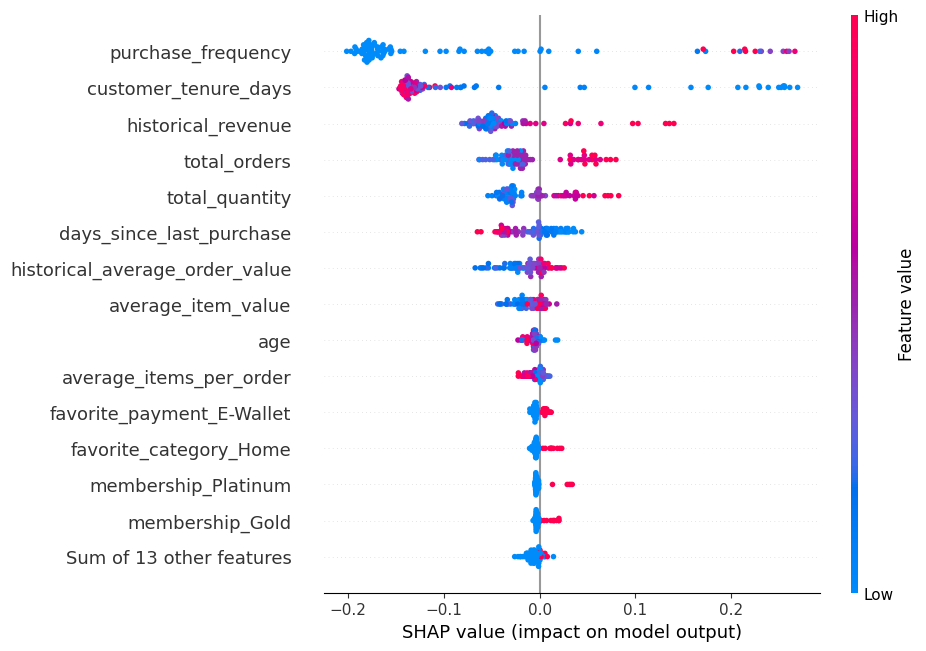

In [6]:
shap.plots.beeswarm(
    shap_values_positive,
    max_display=15
)

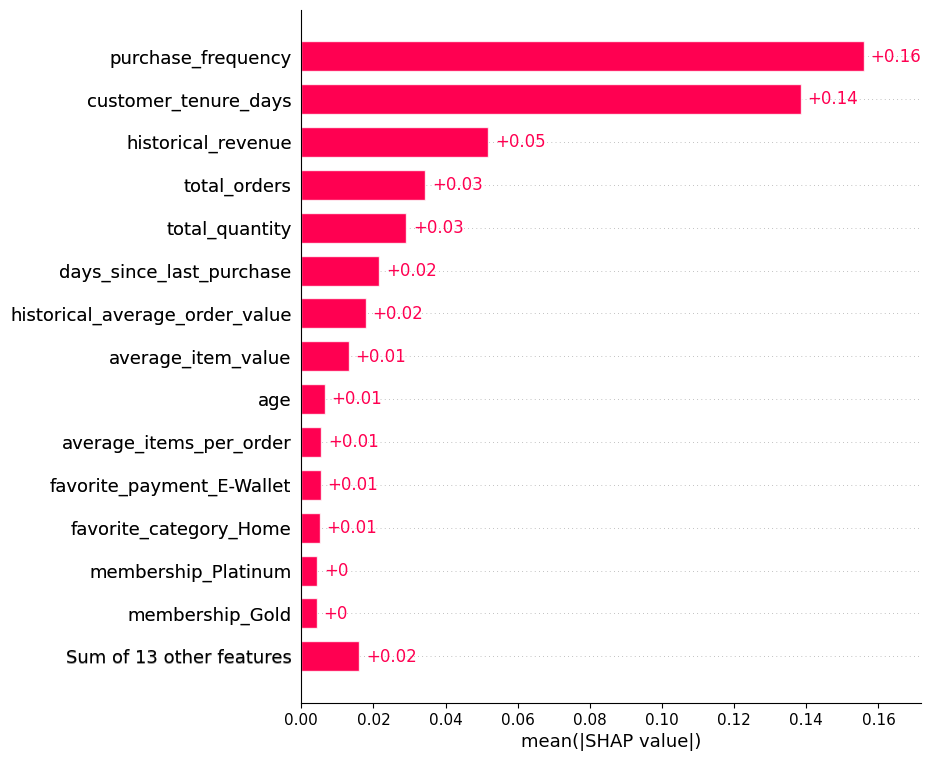

In [7]:
shap.plots.bar(
    shap_values_positive,
    max_display=15
)

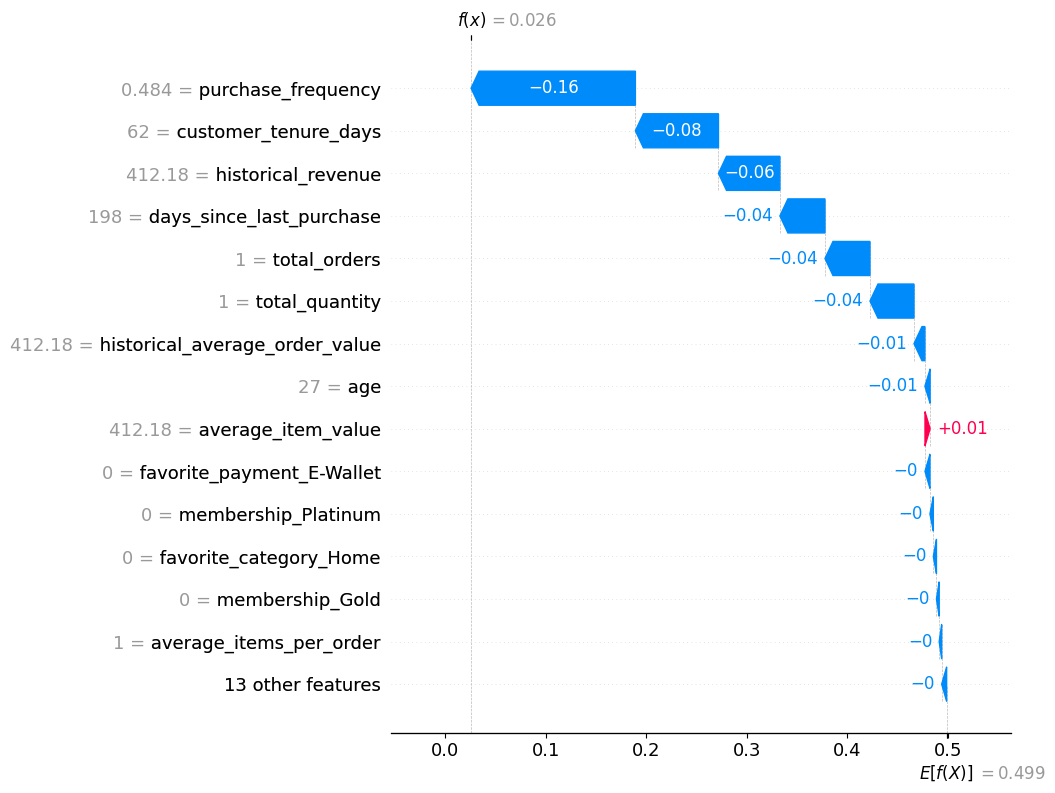

In [8]:
customer_index = 0

shap.plots.waterfall(
    shap_values_positive[customer_index],
    max_display=15
)

In [9]:
predicted_class = model.predict(X_test.iloc[[customer_index]])[0]
probability = model.predict_proba(
    X_test.iloc[[customer_index]]
)[0, 1]

print("Predicted class:", predicted_class)
print(f"High-value probability: {probability:.2%}")

Predicted class: 0
High-value probability: 2.55%


In [10]:
import os

os.makedirs("../screenshots", exist_ok=True)

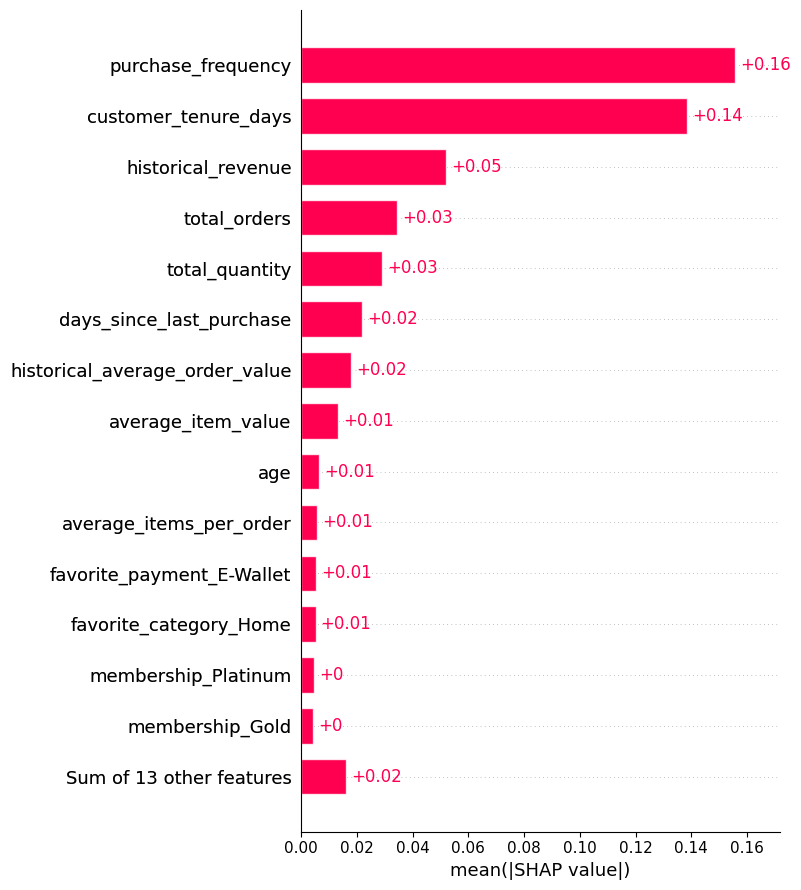

In [11]:
shap.plots.bar(
    shap_values_positive,
    max_display=15,
    show=False
)

plt.tight_layout()
plt.savefig(
    "../screenshots/shap_global_bar.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

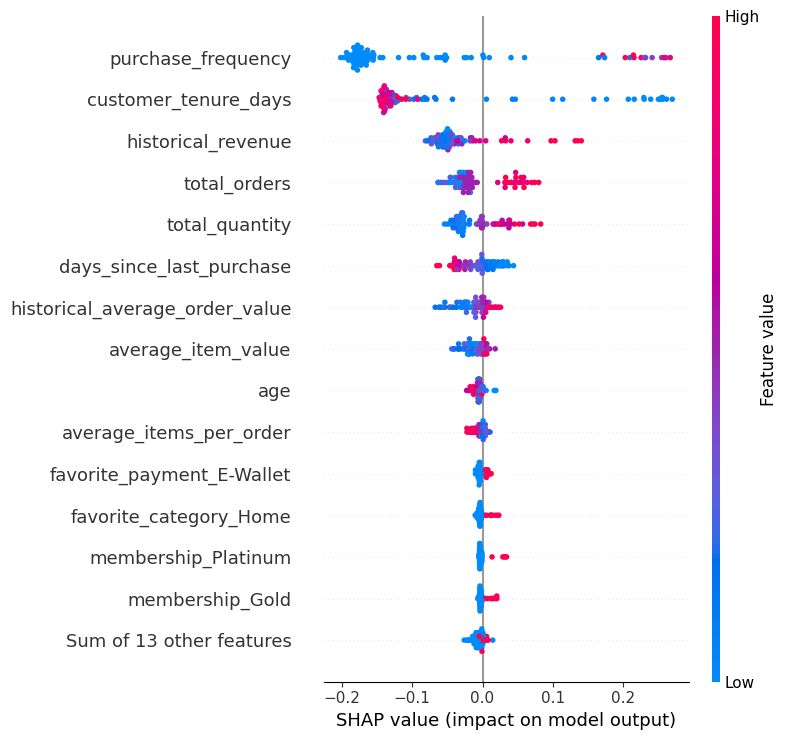

In [12]:
shap.plots.beeswarm(
    shap_values_positive,
    max_display=15,
    show=False
)

plt.tight_layout()
plt.savefig(
    "../screenshots/shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

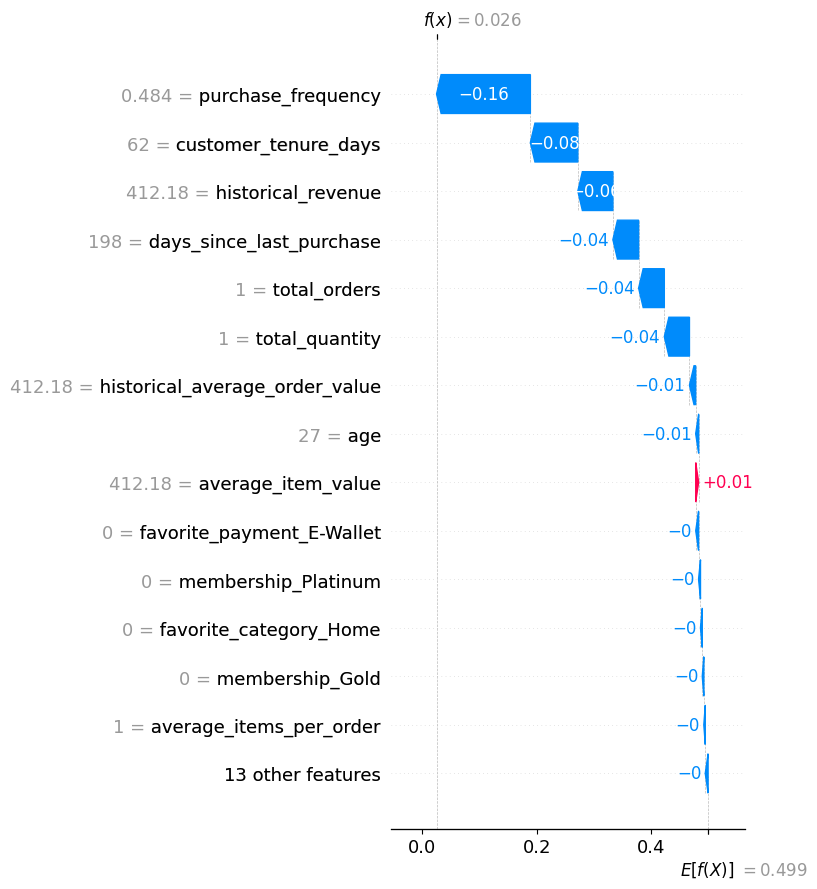

In [13]:
customer_index = 0

shap.plots.waterfall(
    shap_values_positive[customer_index],
    max_display=15,
    show=False
)

plt.tight_layout()
plt.savefig(
    "../screenshots/shap_waterfall_customer_0.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()